In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data = data.dropna(subset=["TotalCharges"]).copy()

revenue_series = (
    data.groupby("tenure")["TotalCharges"]
    .sum()
    .reset_index()
)

revenue_series = revenue_series.sort_values("tenure")

revenue_series["Date"] = pd.date_range(
    start="2020-01-01",
    periods=len(revenue_series),
    freq="MS"
)

revenue_series = revenue_series[
    ["Date", "TotalCharges"]
].set_index("Date")

revenue_series.rename(
    columns={"TotalCharges": "Revenue"},
    inplace=True
)

display(revenue_series.head())
print("Revenue time series prepared!")
print("Number of periods:", len(revenue_series))

,Revenue
Date,
2020-01-01,30947.80
2020-02-01,27211.10
2020-03-01,34938.00
2020-04-01,40573.40
2020-05-01,40497.35


Revenue time series prepared!
Number of periods: 72


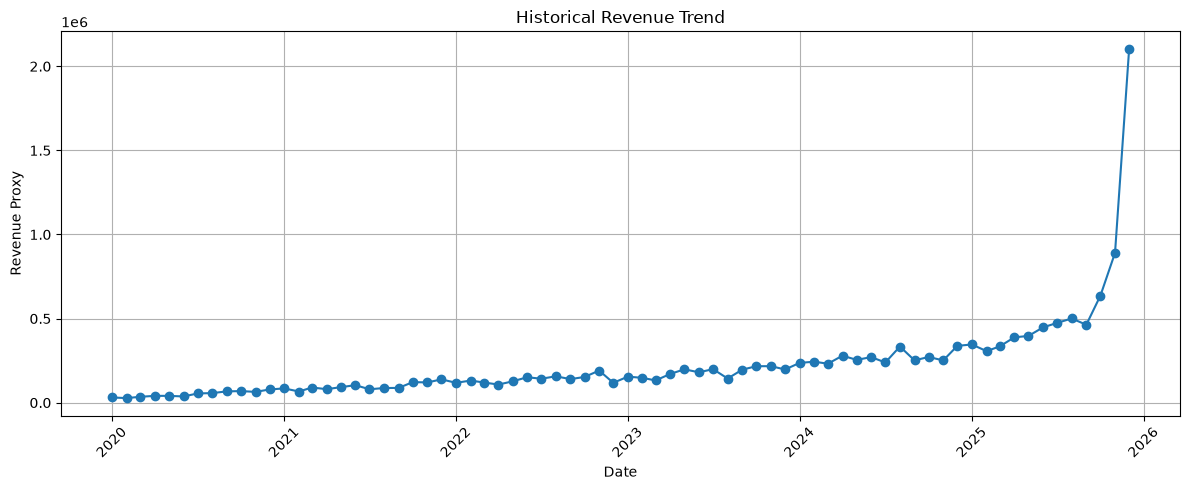

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(
    revenue_series.index,
    revenue_series["Revenue"],
    marker="o"
)

plt.title("Historical Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue Proxy")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "day37_historical_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
arima_model = ARIMA(
    revenue_series["Revenue"],
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                   72
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -937.076
Date:                Thu, 24 Sep 2026   AIC                           1880.152
Time:                        21:34:49   BIC                           1886.940
Sample:                    01-01-2020   HQIC                          1882.851
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.181      5.515      0.000       0.645       1.355
ma.L1         -0.0637      0.423     -0.151      0.880      -0.892       0.765
sigma2      1.207e+10   1.01e-10    1.2e+20      0.0

c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


In [6]:
fitted_values = arima_result.fittedvalues

comparison = pd.DataFrame({
    "Actual Revenue": revenue_series["Revenue"],
    "ARIMA Fitted Revenue": fitted_values
})

display(comparison.head(10))

,Actual Revenue,ARIMA Fitted Revenue
Date,,
2020-01-01,30947.80,0.000000
2020-02-01,27211.10,61893.558518
2020-03-01,34938.00,25673.225225
2020-04-01,40573.40,42074.718890
2020-05-01,40497.35,46304.041359
2020-06-01,36979.25,40790.927252
2020-07-01,54809.20,33703.983573
2020-08-01,56923.05,71294.678097
2020-09-01,67132.80,59951.599131


In [7]:
forecast_steps = 12

future_forecast = arima_result.forecast(
    steps=forecast_steps
)

future_dates = pd.date_range(
    start=revenue_series.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "PredictedRevenue": future_forecast.values
})

display(forecast_df)

,Date,PredictedRevenue
0,2026-01-01,3.256121e+06
1,2026-02-01,4.408071e+06
2,2026-03-01,5.559954e+06
3,2026-04-01,6.711772e+06
4,2026-05-01,7.863522e+06
5,2026-06-01,9.015207e+06
6,2026-07-01,1.016682e+07
7,2026-08-01,1.131838e+07
8,2026-09-01,1.246986e+07
9,2026-10-01,1.362128e+07


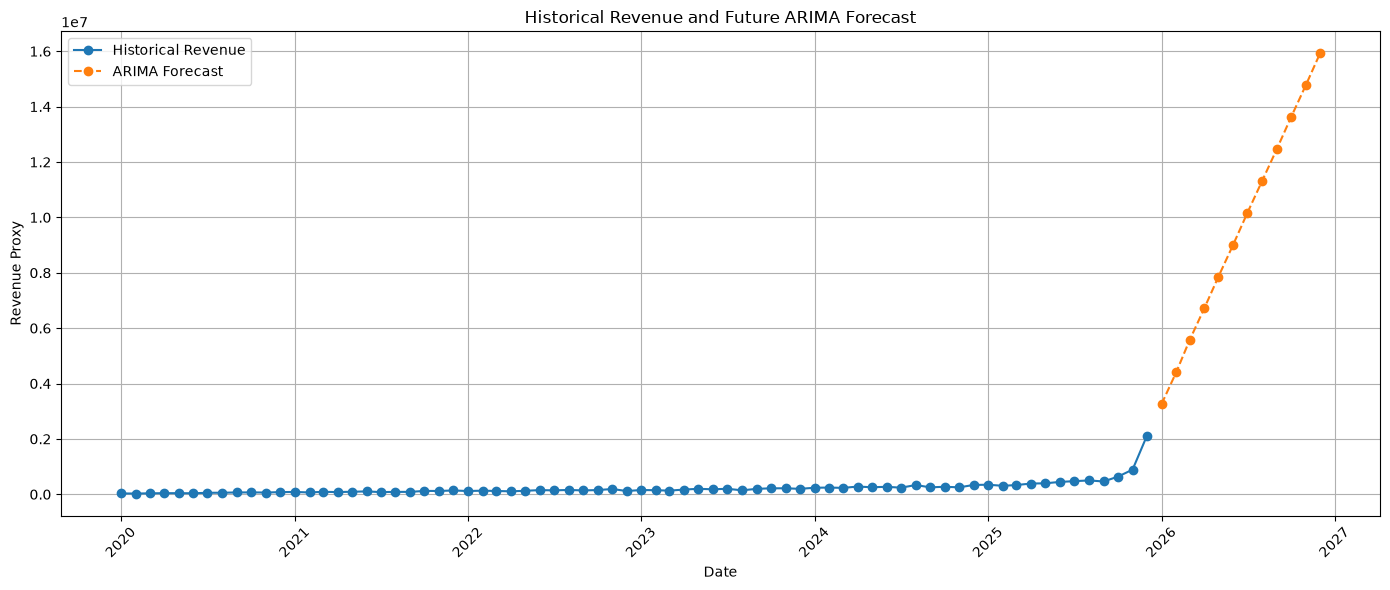

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(
    revenue_series.index,
    revenue_series["Revenue"],
    marker="o",
    label="Historical Revenue"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["PredictedRevenue"],
    marker="o",
    linestyle="--",
    label="ARIMA Forecast"
)

plt.title("Historical Revenue and Future ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue Proxy")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "day37_arima_revenue_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

train = revenue_series["Revenue"].iloc[:-6]
test = revenue_series["Revenue"].iloc[-6:]

validation_model = ARIMA(
    train,
    order=(1, 1, 1)
)

validation_result = validation_model.fit()

validation_forecast = validation_result.forecast(
    steps=len(test)
)

mae = mean_absolute_error(
    test,
    validation_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        validation_forecast
    )
)

print("Validation Results")
print("------------------")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Validation Results
------------------
MAE: 417568.36
RMSE: 715904.38


c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


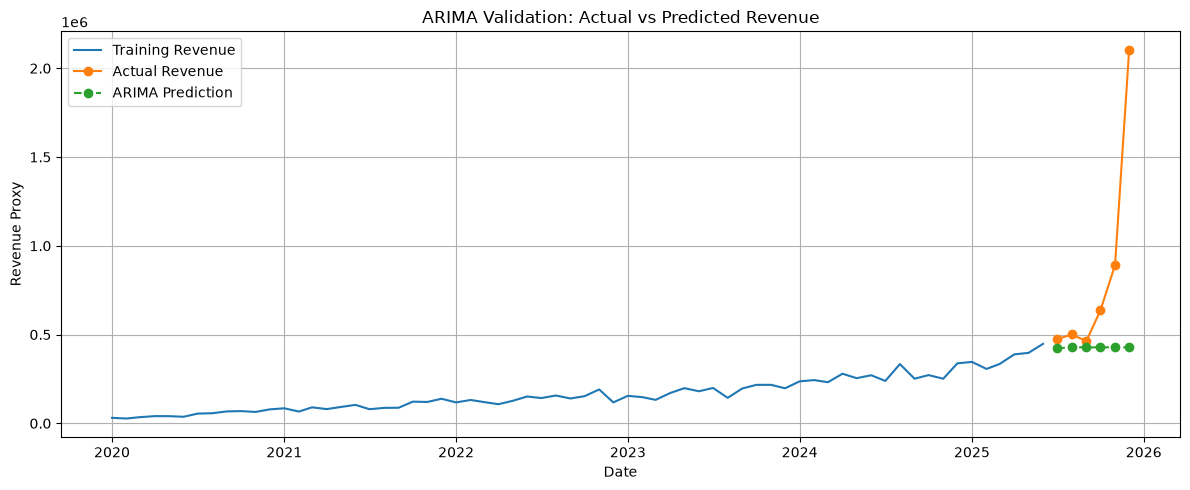

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train,
    label="Training Revenue"
)

plt.plot(
    test.index,
    test,
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    test.index,
    validation_forecast,
    marker="o",
    linestyle="--",
    label="ARIMA Prediction"
)

plt.title("ARIMA Validation: Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue Proxy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "day37_arima_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
forecast_df.to_csv(
    "day37_revenue_forecast.csv",
    index=False
)

accuracy_report = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Value": [mae, rmse]
})

accuracy_report.to_csv(
    "day37_forecast_accuracy.csv",
    index=False
)

print("Forecast outputs saved successfully!")
display(forecast_df)
display(accuracy_report)

Forecast outputs saved successfully!


,Date,PredictedRevenue
0,2026-01-01,3.256121e+06
1,2026-02-01,4.408071e+06
2,2026-03-01,5.559954e+06
3,2026-04-01,6.711772e+06
4,2026-05-01,7.863522e+06
5,2026-06-01,9.015207e+06
6,2026-07-01,1.016682e+07
7,2026-08-01,1.131838e+07
8,2026-09-01,1.246986e+07
9,2026-10-01,1.362128e+07


,Metric,Value
0,MAE,417568.360467
1,RMSE,715904.382369


In [12]:
forecast_summary = pd.DataFrame({
    "Metric": [
        "Average Historical Revenue",
        "Average Forecast Revenue",
        "Minimum Forecast Revenue",
        "Maximum Forecast Revenue",
        "MAE",
        "RMSE"
    ],
    "Value": [
        revenue_series["Revenue"].mean(),
        forecast_df["PredictedRevenue"].mean(),
        forecast_df["PredictedRevenue"].min(),
        forecast_df["PredictedRevenue"].max(),
        mae,
        rmse
    ]
})

display(forecast_summary)

,Metric,Value
0,Average Historical Revenue,2.230023e+05
1,Average Forecast Revenue,9.590629e+06
2,Minimum Forecast Revenue,3.256121e+06
3,Maximum Forecast Revenue,1.592392e+07
4,MAE,4.175684e+05
5,RMSE,7.159044e+05


In [13]:
business_report = f"""
DAY 37 — BUSINESS REVENUE FORECASTING REPORT

Objective
---------
The objective of this analysis was to demonstrate business
revenue forecasting using an ARIMA time-series model.

Data Preparation
----------------
TotalCharges from the Telco customer dataset was used as a
revenue proxy. Customers were grouped by tenure and an
artificial monthly time index was created.

Forecasting Model
-----------------
Model: ARIMA(1,1,1)
Forecast Horizon: 12 periods

Model Validation
----------------
MAE: {mae:.2f}
RMSE: {rmse:.2f}

Forecast Summary
----------------
Average historical revenue: {revenue_series["Revenue"].mean():.2f}
Average forecast revenue: {forecast_df["PredictedRevenue"].mean():.2f}
Minimum forecast revenue: {forecast_df["PredictedRevenue"].min():.2f}
Maximum forecast revenue: {forecast_df["PredictedRevenue"].max():.2f}

Business Implications
---------------------
Revenue forecasts can support:
- Financial planning
- Resource allocation
- Marketing planning
- Investment decisions
- Capacity planning
- Revenue target setting

Forecast Accuracy
-----------------
MAE and RMSE provide measures of the difference between actual
and predicted revenue during validation. Lower values generally
indicate smaller prediction errors on the validation period.

Risks and Limitations
---------------------
1. The source dataset does not contain actual transaction dates.
2. TotalCharges is used as a revenue proxy rather than verified
   time-based company revenue.
3. An artificial monthly index was created for this exercise.
4. The ARIMA model does not include external business variables
   such as promotions, pricing changes, economic conditions, or
   seasonal events.
5. Forecast accuracy can change when future business conditions
   differ from historical patterns.

Conclusion
----------
The ARIMA model demonstrates how historical time-series patterns
can be used to generate future revenue estimates. In a real
business environment, genuine dated revenue data and additional
business variables should be used before making financial
decisions.
"""

print(business_report)

with open(
    "day37_business_forecasting_report.txt",
    "w"
) as file:
    file.write(business_report)


DAY 37 — BUSINESS REVENUE FORECASTING REPORT

Objective
---------
The objective of this analysis was to demonstrate business
revenue forecasting using an ARIMA time-series model.

Data Preparation
----------------
TotalCharges from the Telco customer dataset was used as a
revenue proxy. Customers were grouped by tenure and an
artificial monthly time index was created.

Forecasting Model
-----------------
Model: ARIMA(1,1,1)
Forecast Horizon: 12 periods

Model Validation
----------------
MAE: 417568.36
RMSE: 715904.38

Forecast Summary
----------------
Average historical revenue: 223002.34
Average forecast revenue: 9590628.91
Minimum forecast revenue: 3256121.23
Maximum forecast revenue: 15923920.62

Business Implications
---------------------
Revenue forecasts can support:
- Financial planning
- Resource allocation
- Marketing planning
- Investment decisions
- Capacity planning
- Revenue target setting

Forecast Accuracy
-----------------
MAE and RMSE provide measures of the differenc